# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [5]:
import pandas as pd

titanic_df = pd.read_csv('titanic_passengers.csv')

titanic_df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
titanic_df['Fare'].mean()

32.204207968574636

In [3]:
titanic_df['Fare'].median()

14.4542

In [4]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


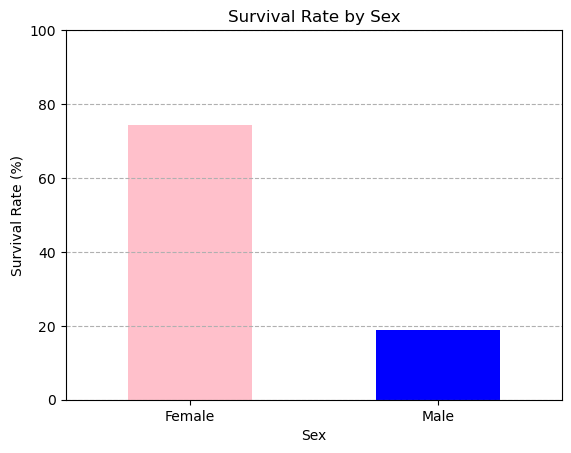

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

titanicDF = pd.read_csv('titanic_passengers.csv')

survivalBySex = titanicDF.groupby('Sex')['Survived'].mean()*100
print(survivalBySex)

survivalBySex.plot(kind='bar', color= ['pink', 'blue'])
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.xticks([0,1], ['Female','Male'], rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

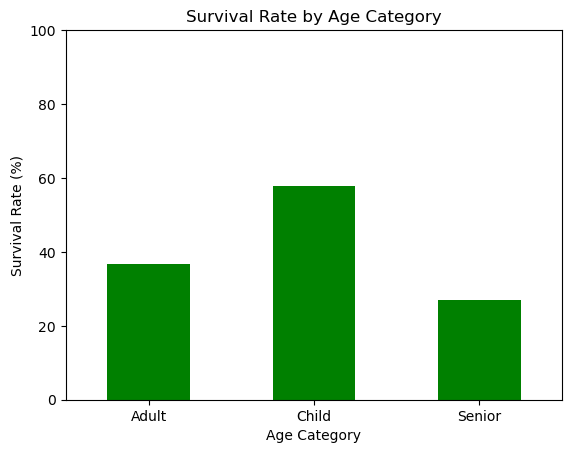

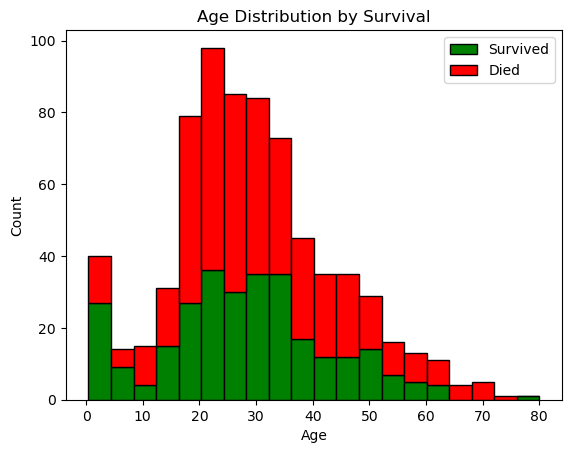

In [46]:
titanicDF['Age_Category'] = 'Adult'
titanicDF.loc[titanicDF['Age'] < 15, 'Age_Category'] = 'Child'
titanicDF.loc[titanicDF['Age'] >= 60, 'Age_Category'] = 'Senior'

survivalByAge = titanicDF.groupby('Age_Category')['Survived'].mean()*100
survivalByAge.plot(kind='bar', color='green')
plt.title('Survival Rate by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

plt.hist([titanicDF[titanicDF['Survived']==1]['Age'].dropna(), titanicDF[titanicDF['Survived']==0]['Age'].dropna()],
         stacked=True, bins=20, label=['Survived', 'Died'], color=['green', 'red'], edgecolor= 'black')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

I chose to seperate age groups by standard age ranges,
15 and under are children
16 - 59 are adults 
and anyone over 60 is a senior

from the graphs it looks like the best chance for survival was for children, specifically those under the age of 10

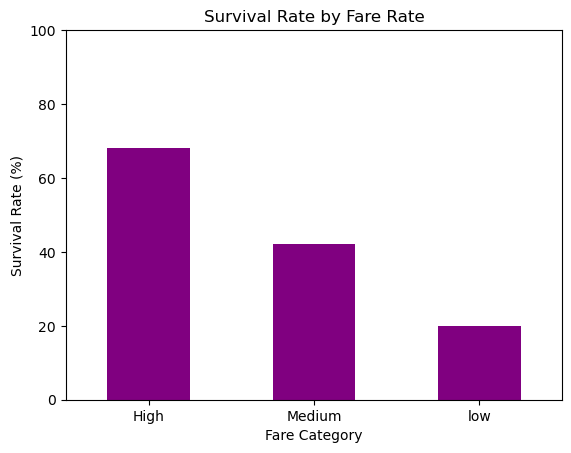

In [25]:
titanicDF['Fare_Category'] = 'low'
titanicDF.loc[(titanicDF['Fare'] > 10)& (titanicDF['Fare'] <= 50), 'Fare_Category'] = 'Medium'
titanicDF.loc[titanicDF['Fare'] > 50, 'Fare_Category'] = 'High'

survivalByFare = titanicDF.groupby('Fare_Category')['Survived'].mean()*100
survivalByFare.plot(kind='bar', color='purple')
plt.title('Survival Rate by Fare Rate')
plt.xlabel('Fare Category')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()


For the fare rate survival i seperated them into 3 category's, 
low < 10
medium > 10 < 50
high > 50

The best chance of survival when it comes to the fare rate is to spend more money. At least more than 10 pounds which is about 35 dollars or $1,134 in todays Currency

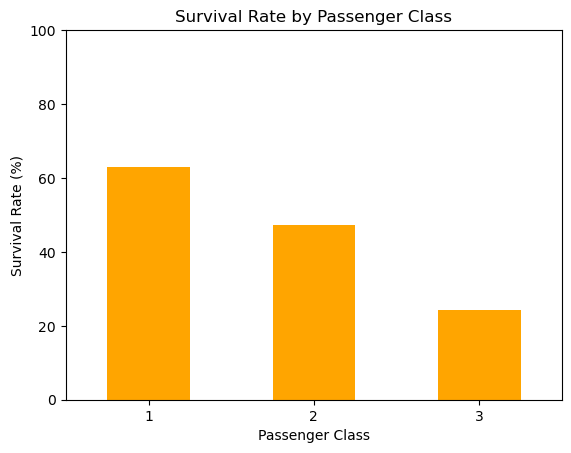

In [31]:
survivalByClass = titanicDF.groupby('Pclass')['Survived'].mean()*100

survivalByClass.plot(kind='bar', color='orange')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

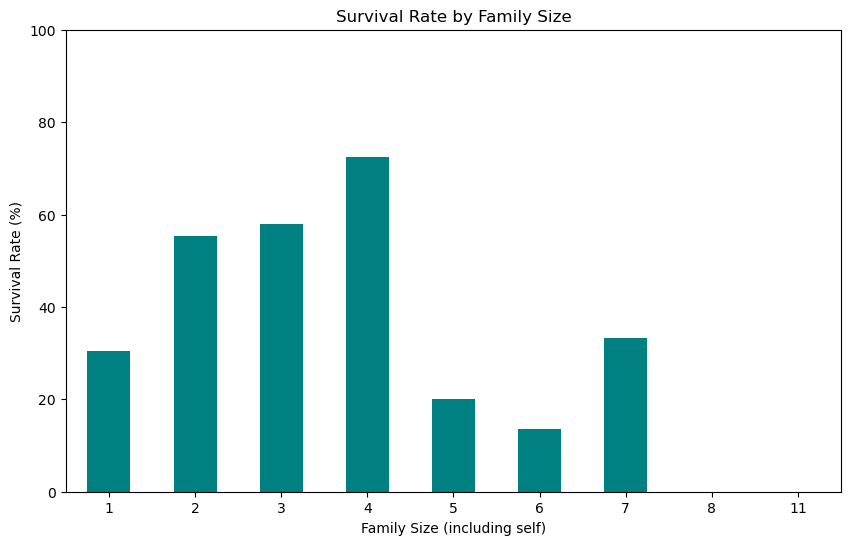

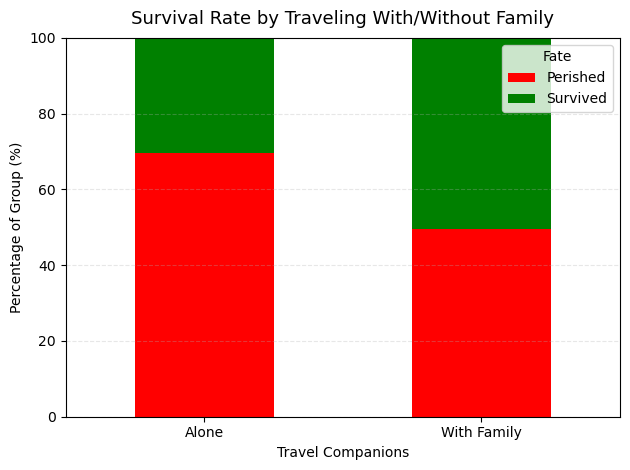

In [36]:
titanicDF['Family_Size'] = titanicDF['SibSp'] + titanicDF['Parch'] + 1  # +1 for self

survivalByFamily = titanicDF.groupby('Family_Size')['Survived'].mean() * 100

plt.figure(figsize=(10, 6))
survivalByFamily.plot(kind='bar', color='teal')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation = 0)
plt.show()


titanicDF['Has_Family'] = (titanicDF['SibSp'] > 0) | (titanicDF['Parch'] > 0)
titanicDF['Family_Status'] = titanicDF['Has_Family'].map({True: 'With Family', False: 'Alone'})

family_crosstab = pd.crosstab(
    titanicDF['Family_Status'], 
    titanicDF['Survived'], 
    normalize='index'
) * 100

family_crosstab.plot(
    kind='bar', 
    stacked=True,           
    color=['red', 'green']
)

plt.title('Survival Rate by Traveling With/Without Family', fontsize=13, pad=10)
plt.ylabel('Percentage of Group (%)')
plt.xlabel('Travel Companions')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(['Perished', 'Survived'], title='Fate', loc='upper right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

If you where alone you had the least chance of survival, you had a much better chance if you had any sort of family. mostly families with 4 members on board survived, likely due to the Mother and children surviving and the father dying but still a better chance.


Passengers by Port:
S: 644 passengers
C: 168 passengers
Q: 77 passengers


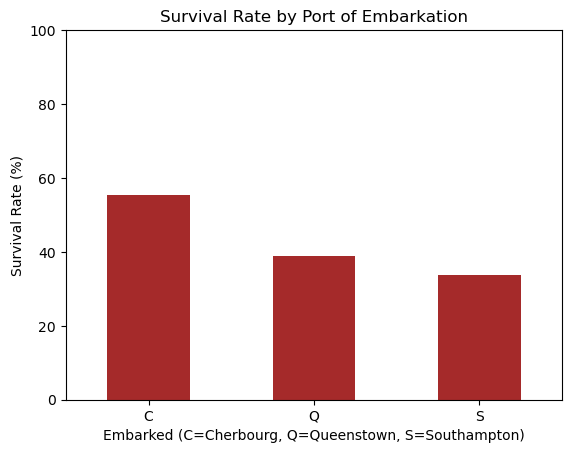

In [39]:
embarkCounts = titanicDF['Embarked'].value_counts()

print("\nPassengers by Port:")
for port, count in embarkCounts.items():
    print(f"{port}: {count} passengers")

survivalByEmbarked = titanicDF.groupby('Embarked')['Survived'].mean() * 100

survivalByEmbarked.plot(kind='bar', color='brown')
plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

you have the best chance of surviving if you embarked at port Cherbourg(C) but port S I feel is only the lowest because of the shear amount of passengers that came aboard. 

In [42]:
mostLikely = titanicDF[
    (titanicDF['Sex'] == 'female') &
    (titanicDF['Pclass'] == 1) &
    (titanicDF['Age'] < 15) &                     
    (titanicDF['Fare'] > 50) &                    
    ((titanicDF['SibSp'] + titanicDF['Parch']) >= 1) &               
    (titanicDF['Survived'] == 1)                  
]

print("Most likely to survive candidates:")
print(mostLikely[['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'SibSp', 'Parch', 'Embarked', 'Survived']].head(5))

Most likely to survive candidates (showing top few):
                          Name   Age     Sex  Pclass   Fare  SibSp  Parch  \
435  Carter, Miss. Lucile Polk  14.0  female       1  120.0      1      2   

    Embarked  Survived  
435        S         1  


The most likely person to survive is Miss. Lucile Polk, a 14 year old girl from Pennsylvania that embarked at port Southampton. Miss. Polk boarded the Titanic with her parents and brother as first class passengers, the family had multiple servents that joind them but their chauffeur was forced to travelled in second class. During the tragedy, she boarded lifeboat 4 with her mother and brother as well as thier maid, Miss Serreplaa. They had a dog with them on the journy but where forced to leave them behind.

In [43]:
least_likely = titanicDF[
    (titanicDF['Sex'] == 'male') &
    (titanicDF['Pclass'] == 3) &
    (titanicDF['Age'] >= 18) &                  
    (titanicDF['Age'] < 60) &                  
    (titanicDF['Fare'] <= 10) &              
    (titanicDF['SibSp'] + titanicDF['Parch'] == 0) &    
    (titanicDF['Embarked'] == 'S') &
    (titanicDF['Survived'] == 0)                  
]

print("\nLeast likely to survive candidates (top 5):")
print(least_likely[['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'SibSp', 'Parch', 'Embarked', 'Survived']].head(5))


Least likely to survive candidates (showing top few):
                              Name   Age   Sex  Pclass    Fare  SibSp  Parch  \
4         Allen, Mr. William Henry  35.0  male       3  8.0500      0      0   
12  Saundercock, Mr. William Henry  20.0  male       3  8.0500      0      0   
37        Cann, Mr. Ernest Charles  21.0  male       3  8.0500      0      0   
51    Nosworthy, Mr. Richard Cater  21.0  male       3  7.8000      0      0   
67        Crease, Mr. Ernest James  19.0  male       3  8.1583      0      0   

   Embarked  Survived  
4         S         0  
12        S         0  
37        S         0  
51        S         0  
67        S         0  


The least likely person to survive the Titanic would be Mr. Richard Cater, a single 21 year old man from Devon England. Mr. Cater originaly booked passage on the Olympic but due to disruption, his journy to Southampton was halted at Exter. He boarded the Titanic at Southampton as a third class passenger but his destination was unknown. He was lost in the sinking and his body was never identified.